In [ ]:
!rm -rf "/content/chompa-pose-3" "/content/chompa_pose.yaml" "/content/train_1024" "/content/valid_1024" "/content/train_aug"

# Instalar Librerias

In [1]:
# Instalación de las librerías base y las dependencias dinámicas del modelo
!pip install transformers accelerate opencv-python pillow numpy
!pip install kornia  # <--- Esta es la que causó el error
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 82.5 MB/s eta 0:00:00
Looking in indexes: https://download.pytorch.org/whl/cu121


In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.2 MB/s eta 0:00:00


In [3]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 132.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


# Importar datos de Roboflow

In [4]:
from roboflow import Roboflow
rf = Roboflow(api_key="1R7MU271paGABydiZOwH")
project = rf.workspace("clothesdataset-yimbv").project("chompa-pose")
version = project.version(3)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to chompa-pose-3 in yolov8:: 100%|██████████| 94/94 [00:00<00:00, 1373.83it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Segmentacion con BiRefNet

In [5]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
from roboflow import Roboflow
from transformers import AutoModelForImageSegmentation
from torchvision import transforms

In [6]:
# 1. Configurar dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando: {device}")

# 2. Cargar el modelo
# trust_remote_code=True es necesario porque BiRefNet tiene código personalizado en el Hub
try:
    model = AutoModelForImageSegmentation.from_pretrained(
        "ZhengPeng7/BiRefNet",
        trust_remote_code=True
    )
    model.to(device).float()
    model.eval()
    print("¡Modelo BiRefNet cargado exitosamente!")
except ImportError as e:
    print(f"Error de importación: {e}. Intenta ejecutar '!pip install kornia' nuevamente.")


# Transformación para la entrada del modelo
biref_transform = transforms.Compose([
    transforms.Resize((1024, 1024)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def process_dataset(input_img_dir, output_img_dir, TARGET_SIZE):

    if not os.path.exists(output_img_dir): os.makedirs(output_img_dir)
    metadata = {}

    for img_name in os.listdir(input_img_dir):
        if not img_name.endswith(('.jpg', '.png', '.jpeg')): continue

        path = os.path.join(input_img_dir, img_name)
        img_pil = Image.open(path).convert("RGB")
        w_orig, h_orig = img_pil.size

        # Inferencia BiRefNet (Se mantiene igual, el modelo internamente usa 1024)
        input_tensor = biref_transform(img_pil).unsqueeze(0).to(device).float()
        with torch.no_grad():
            preds = model(input_tensor)[-1].sigmoid().cpu().numpy()[0, 0]

        mask = cv2.resize(preds, (w_orig, h_orig))
        binary_mask = (mask > 0.5).astype(np.uint8)

        # Hallar BBox del objeto segmentado
        coords = np.column_stack(np.where(binary_mask > 0))
        if coords.size == 0: continue
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)

        # Margen 20%
        bw, bh = x_max - x_min, y_max - y_min
        x_min = max(0, x_min - int(bw * 0.2))
        y_min = max(0, y_min - int(bh * 0.2))
        x_max = min(w_orig, x_max + int(bw * 0.2))
        y_max = min(h_orig, y_max + int(bh * 0.2))

        # Recorte y Fondo Negro
        img_cv = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
        crop = img_cv[y_min:y_max, x_min:x_max]
        mask_crop = binary_mask[y_min:y_max, x_min:x_max]
        clean_crop = cv2.bitwise_and(crop, crop, mask=mask_crop)

        # Letterbox a TARGET_SIZE
        h, w = clean_crop.shape[:2]
        max_side = max(h, w)
        canvas = np.zeros((max_side, max_side, 3), dtype=np.uint8)
        off_x, off_y = (max_side - w) // 2, (max_side - h) // 2
        canvas[off_y:off_y+h, off_x:off_x+w] = clean_crop

        # Redimensionar a 1024x1024
        final_img = cv2.resize(canvas, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_LANCZOS4) ### CAMBIO ###

        # Guardar imagen y metadatos con el nuevo factor de escala
        cv2.imwrite(os.path.join(output_img_dir, img_name), final_img)
        # El factor ahora es 1024/max_side
        metadata[img_name] = (x_min, y_min, off_x, off_y, TARGET_SIZE/max_side) ### CAMBIO ###

    return metadata

# Definimos el nuevo tamaño objetivo
TARGET_SIZE = 1280

# Actualizamos los nombres de las carpetas de salida para ser ordenados
meta_train = process_dataset(f"{dataset.location}/train/images", f"train_{TARGET_SIZE}/images",TARGET_SIZE)
meta_valid = process_dataset(f"{dataset.location}/valid/images", f"valid_{TARGET_SIZE}/images",TARGET_SIZE)


Usando: cuda



The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


config.json:   0%|          | 0.00/405 [00:00<?, ?B/s]

BiRefNet_config.py:   0%|          | 0.00/298 [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ZhengPeng7/BiRefNet:
- BiRefNet_config.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


birefnet.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ZhengPeng7/BiRefNet:
- birefnet.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/444M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/754 [00:00<?, ?it/s]

¡Modelo BiRefNet cargado exitosamente!


In [7]:
import os
from PIL import Image

def transform_labels_v3_dynamic(input_img_dir, input_label_dir, output_label_dir, metadata_dict, TARGET_SIZE):
    if not os.path.exists(output_label_dir): os.makedirs(output_label_dir)

    for img_name, (x_min, y_min, off_x, off_y, scale) in metadata_dict.items():
        label_name = os.path.splitext(img_name)[0] + ".txt"

        # 1. Obtener dimensiones REALES
        orig_img_path = os.path.join(input_img_dir, img_name)
        with Image.open(orig_img_path) as temp_img:
            orig_w, orig_h = temp_img.size

        input_path = os.path.join(input_label_dir, label_name)
        output_path = os.path.join(output_label_dir, label_name)

        if not os.path.exists(input_path): continue

        with open(input_path, 'r') as f:
            lines = f.readlines()

        new_lines = []
        for line in lines:
            parts = line.split()
            class_id = parts[0]

            # Listas para encontrar los extremos de los keypoints
            temp_kpts_x = []
            temp_kpts_y = []
            kpts_formatted = []

            # 2. Transformar Keypoints primero
            for i in range(5, len(parts), 3):
                kx_orig = float(parts[i]) * orig_w
                ky_orig = float(parts[i+1]) * orig_h
                v = parts[i+2]

                # Transformación al nuevo lienzo 960x960
                kx_final = ((kx_orig - x_min) + off_x) * scale / TARGET_SIZE
                ky_final = ((ky_orig - y_min) + off_y) * scale / TARGET_SIZE

                # Asegurar rango [0, 1]
                kx_final = max(0, min(1, kx_final))
                ky_final = max(0, min(1, ky_final))

                temp_kpts_x.append(kx_final)
                temp_kpts_y.append(ky_final)
                kpts_formatted.extend([f"{kx_final:.6f}", f"{ky_final:.6f}", v])

            # 3. Calcular BBox DINÁMICO basado en los Keypoints
            # Buscamos los valores mínimos y máximos
            xmin_kp, xmax_kp = min(temp_kpts_x), max(temp_kpts_x)
            ymin_kp, ymax_kp = min(temp_kpts_y), max(temp_kpts_y)

            # Añadimos un margen del 3% para que el BBox no toque exactamente el punto
            margin = 0.03
            x1 = max(0, xmin_kp - margin)
            y1 = max(0, ymin_kp - margin)
            x2 = min(1, xmax_kp + margin)
            y2 = min(1, ymax_kp + margin)

            # Convertir a formato YOLO (center_x, center_y, width, height)
            bbox_w = x2 - x1
            bbox_h = y2 - y1
            bbox_xc = x1 + (bbox_w / 2)
            bbox_yc = y1 + (bbox_h / 2)

            # Unir todo: Clase + BBox dinámico + Keypoints
            final_parts = [class_id, f"{bbox_xc:.6f}", f"{bbox_yc:.6f}", f"{bbox_w:.6f}", f"{bbox_h:.6f}"] + kpts_formatted
            new_lines.append(" ".join(final_parts))

        with open(output_path, 'w') as f:
            f.write("\n".join(new_lines))

    print(f"Etiquetas con BBox dinámico generadas con éxito en {output_label_dir}.")

# Ejecutar para entrenamiento
transform_labels_v3_dynamic(
    f"{dataset.location}/train/images",
    f"{dataset.location}/train/labels",
    f"train_{TARGET_SIZE}/labels",
    meta_train, TARGET_SIZE
)

# Ejecutar para validacion
transform_labels_v3_dynamic(
    f"{dataset.location}/valid/images",
    f"{dataset.location}/valid/labels",
    f"valid_{TARGET_SIZE}/labels",
    meta_valid, TARGET_SIZE
)

Etiquetas con BBox dinámico generadas con éxito en train_1280/labels.
Etiquetas con BBox dinámico generadas con éxito en valid_1280/labels.


# Verificacion de Etiquetado

65 346 1280 917


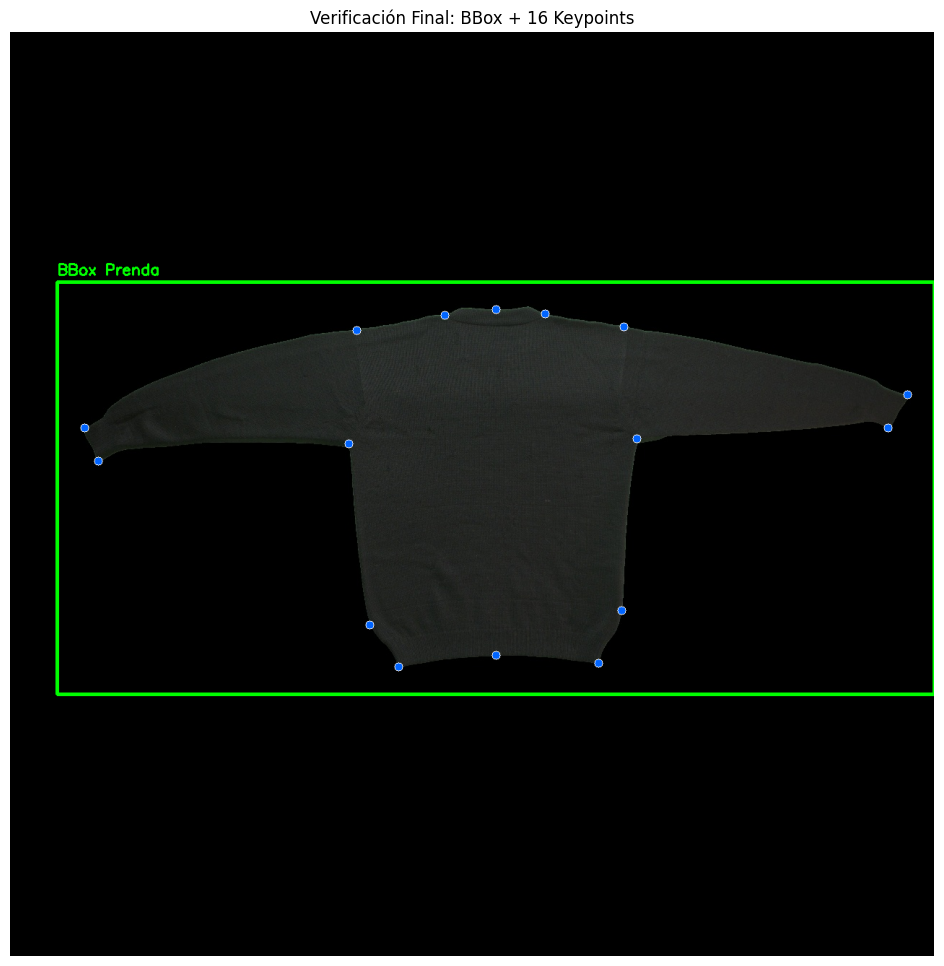

In [8]:
import matplotlib.pyplot as plt
import cv2

imagen = 'tmp79u96h3m_jpg.rf.5f62ae44dc577b02d02071112f33a898'

def verify_alignment_with_bbox(img_path, label_path):
    # Leer imagen
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_img, w_img, _ = img.shape

    with open(label_path, 'r') as f:
        line = f.readline().split()
        if not line: return

        # 1. Extraer y dibujar Bounding Box (Índices 1 a 4)
        # YOLO: x_center, y_center, width, height (normalizados)
        xc, yc, w, h = float(line[1]), float(line[2]), float(line[3]), float(line[4])

        # Convertir a coordenadas de esquina (píxeles)
        x1 = int((xc - w/2) * w_img)
        y1 = int((yc - h/2) * h_img)
        x2 = int((xc + w/2) * w_img)
        y2 = int((yc + h/2) * h_img)

        print(x1,y1,x2,y2)
        # Dibujar rectángulo verde para el BBox
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv2.putText(img, "BBox Prenda", (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        # 2. Extraer y dibujar Keypoints (Índice 5 en adelante)
        for i in range(5, len(line), 3):
            px = float(line[i]) * w_img
            py = float(line[i+1]) * h_img
            # Dibujar puntos azules
            cv2.circle(img, (int(px), int(py)), 5, (0, 100, 255), -1)
            # Dibujar un pequeño borde blanco para que resalten
            cv2.circle(img, (int(px), int(py)), 6, (255, 255, 255), 1)

    plt.figure(figsize=(12, 12))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Verificación Final: BBox + 16 Keypoints")
    plt.show()

# Ejecutar verificación
verify_alignment_with_bbox(
    f"valid_{TARGET_SIZE}/images/{imagen}.jpg",
    f"valid_{TARGET_SIZE}/labels/{imagen}.txt"
)

In [9]:
import cv2
import os
import glob
import random
import matplotlib.pyplot as plt

def visualize_random_enhanced(original_folder, enhanced_folder):
    # 1. Obtener lista de imágenes en la carpeta mejorada
    enhanced_images = glob.glob(os.path.join(enhanced_folder, "*.jpg"))

    if not enhanced_images:
        print(f"❌ No se encontraron imágenes en {enhanced_folder}")
        return

    # 2. Elegir una imagen aleatoria
    random_enhanced_path = random.choice(enhanced_images)
    filename = os.path.basename(random_enhanced_path)
    original_path = os.path.join(original_folder, filename)

    # 3. Leer las imágenes
    img_orig = cv2.imread(original_path)
    img_enh = cv2.imread(random_enhanced_path)

    # Convertir de BGR a RGB para mostrar correctamente con Matplotlib
    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    img_enh = cv2.cvtColor(img_enh, cv2.COLOR_BGR2RGB)

    # 4. Crear la visualización
    plt.figure(figsize=(15, 7))

    # Imagen Original
    plt.subplot(1, 2, 1)
    plt.imshow(img_orig)
    plt.title(f"Original: {filename}")
    plt.axis('off')

    # Imagen con CLAHE
    plt.subplot(1, 2, 2)
    plt.imshow(img_enh)
    plt.title(f"Con CLAHE (Mejor contraste en puños)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Ejecutar para revisar el set de entrenamiento
visualize_random_enhanced('train_960/images', 'train_960/images_enhanced')

❌ No se encontraron imágenes en train_960/images_enhanced


# Aumento de data

In [10]:
import albumentations as A
import cv2
import os
import numpy as np

INPUT_IMG_AUG = f"train_{TARGET_SIZE}/images"
INPUT_LBL_AUG = f"train_{TARGET_SIZE}/labels"
OUTPUT_IMG_AUG = "train_aug/images"
OUTPUT_LBL_AUG = "train_aug/labels"

# 1. Definir el Pipeline (Seguro para Metrología)
transform = A.Compose([
    #A.HorizontalFlip(p=0.5),
    # Bajamos un poco el contraste para no "quemar" los bordes
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.4),
    A.Rotate(
        limit=15,
        border_mode=cv2.BORDER_CONSTANT,
        fill_value=0,
        interpolation=cv2.INTER_LANCZOS4, # CRÍTICO: Mantiene el borde nítido
        p=0.5
    ),
    # GaussNoise casi imperceptible para no deformar el borde
    A.GaussNoise(std_range=(0.01, 0.02), p=0.2),
], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

def augment_dataset(img_dir, label_dir, output_img_dir, output_label_dir, n_variants=5):
    if not os.path.exists(output_img_dir): os.makedirs(output_img_dir)
    if not os.path.exists(output_label_dir): os.makedirs(output_label_dir)

    img_files = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))]

    print(f"Iniciando aumento de {len(img_files)} imágenes...")

    for img_name in img_files:
        # Cargar imagen
        img_path = os.path.join(img_dir, img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w, _ = image.shape

        # Cargar etiquetas (Keypoints)
        label_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + ".txt")
        if not os.path.exists(label_path): continue

        with open(label_path, 'r') as f:
            line = f.readline().split()
            class_id = line[0]
            # Extraer solo x, y de los keypoints (ignorando visibilidad temporalmente)
            kpts = []
            visibilities = []
            for i in range(5, len(line), 3):
                kpts.append([float(line[i]) * w, float(line[i+1]) * h])
                visibilities.append(line[i+2])

        # Generar variantes
        for v in range(n_variants):
            transformed = transform(image=image, keypoints=kpts)
            t_image = transformed['image']
            t_kpts = transformed['keypoints']

            # Nombre de archivo único
            new_name = f"aug_{v}_{img_name}"

            # Guardar Imagen
            cv2.imwrite(os.path.join(output_img_dir, new_name), cv2.cvtColor(t_image, cv2.COLOR_RGB2BGR))

            # Guardar Label (con el BBox recalculado para la nueva posición)
            t_kpts_np = np.array(t_kpts)
            # Normalizar de nuevo
            t_kpts_norm = t_kpts_np / [w, h]

            # Recalcular BBox dinámico para la variante aumentada
            x_min, y_min = np.min(t_kpts_norm, axis=0)
            x_max, y_max = np.max(t_kpts_norm, axis=0)

            margin = 0.03
            bx1, by1 = max(0, x_min - margin), max(0, y_min - margin)
            bx2, by2 = min(1, x_max + margin), min(1, y_max + margin)

            bw, bh = bx2 - bx1, by2 - by1
            bcx, bcy = bx1 + bw/2, by1 + bh/2

            # Formatear línea final
            new_parts = [class_id, f"{bcx:.6f}", f"{bcy:.6f}", f"{bw:.6f}", f"{bh:.6f}"]
            for i, (kx, ky) in enumerate(t_kpts_norm):
                new_parts.extend([f"{kx:.6f}", f"{ky:.6f}", visibilities[i]])

            with open(os.path.join(output_label_dir, os.path.splitext(new_name)[0] + ".txt"), 'w') as f:
                f.write(" ".join(new_parts))

    print(f"¡Hecho! Dataset multiplicado. Ahora tienes aproximadamente {len(img_files) * n_variants} imágenes.")

# Ejecutar (Aumentar x5)
augment_dataset(INPUT_IMG_AUG, INPUT_LBL_AUG, OUTPUT_IMG_AUG, OUTPUT_LBL_AUG, n_variants=5)

Argument(s) 'fill_value' are not valid for transform Rotate


Iniciando aumento de 31 imágenes...
¡Hecho! Dataset multiplicado. Ahora tienes aproximadamente 155 imágenes.


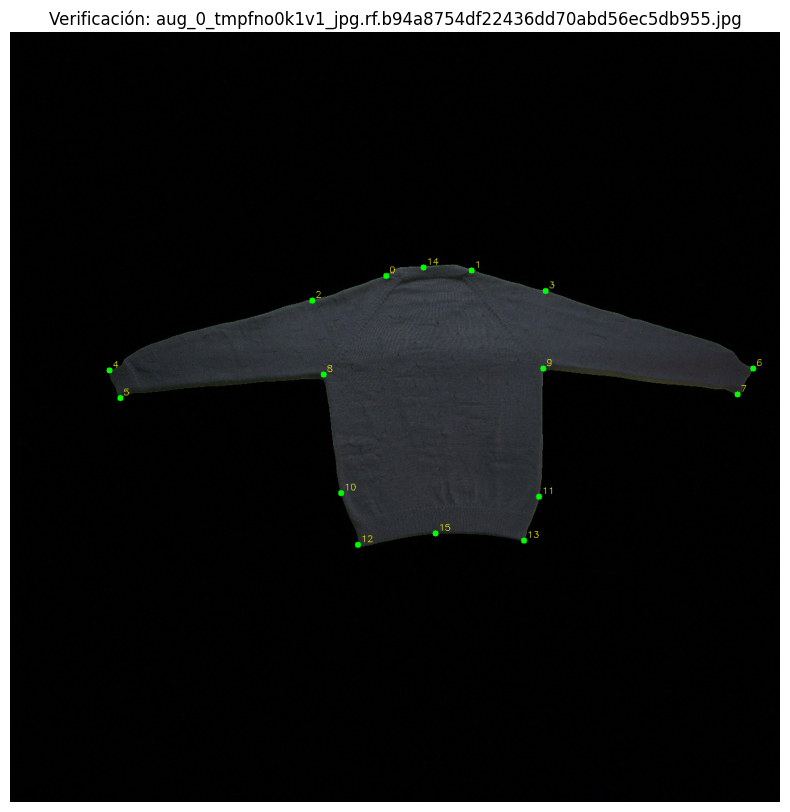

In [11]:
import cv2
import matplotlib.pyplot as plt
import os
import random

def verificar_aumento(img_dir, label_dir):
    # Seleccionar una imagen al azar de las aumentadas
    img_name = random.choice(os.listdir(img_dir))
    img_path = os.path.join(img_dir, img_name)
    label_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + ".txt")

    # Leer imagen
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    # Leer etiquetas
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.split()
            # Los keypoints empiezan en el índice 5 (después de class, cx, cy, w, h)
            kpts = parts[5:]

            for i in range(0, len(kpts), 3):
                kx = float(kpts[i]) * w
                ky = float(kpts[i+1]) * h
                # Dibujar punto y número para verificar el orden
                cv2.circle(image, (int(kx), int(ky)), 5, (0, 255, 0), -1)
                cv2.putText(image, str(i//3), (int(kx)+5, int(ky)-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)

    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.title(f"Verificación: {img_name}")
    plt.axis('off')
    plt.show()

# Ejecutar verificación
verificar_aumento("train_aug/images", "train_aug/labels")

# Generar data.yaml

In [12]:
import yaml

# Mapa de simetría basado en tu imagen de verificación
# El índice representa el punto original, el valor es su pareja al voltear la imagen.
# Posición:  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15
flip_idx = [1, 0, 3, 2, 6, 7, 4, 5, 9, 8, 11, 10, 13, 12, 14, 15]

data_config = {
    'path': '/content',
    'train': 'train_aug/images',
    'val': f'valid_{TARGET_SIZE}/images',
    'nc': 1,
    'names': ['chompa'],
    'kpt_shape': [16, 3], # 16 puntos, (x, y, visibilidad)
    'flip_idx': flip_idx
}

with open('chompa_pose.yaml', 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("✅ 'chompa_pose.yaml' creado con el mapa de simetría correcto.")

✅ 'chompa_pose.yaml' creado con el mapa de simetría correcto.


# Transfer Learning

In [ ]:
print('Listo para entrenamiento Vs9')

Listo para entrenamiento Vs9


## Version 6

In [ ]:
import torch
from ultralytics import YOLO

torch.cuda.empty_cache()

# 1. Cargamos el modelo SMALL
model = YOLO('yolo11s-pose.pt')

# 2. Entrenamiento v6 (Estrategia de Precisión Extrema)
results = model.train(
    data='chompa_pose.yaml',
    imgsz=1024,                   # 1. CAMBIO: Subimos a 1024 para aprovechar tu nuevo pre-procesamiento
    epochs=150,
    batch=8,                      # Si da error de memoria a 1024px, baja a 4 o 6

    # --- PESOS DE PRECISIÓN (CIRUGÍA PARA PUÑOS) ---
    lr0=0.001,
    pose=50.0,                    # 2. CAMBIO: Doblamos la importancia (de 25 a 50). Prioridad total a la ubicación del punto.
    kobj=15.0,                    # 3. CAMBIO: Triplicamos (de 5 a 15). Castigo severo si el punto desaparece.
    label_smoothing=0.05,         # 4. CAMBIO: Menos suavizado para que sea más estricto con el borde real.

    # --- LIMPIEZA VISUAL (CRÍTICO) ---
    fliplr=0.5,
    mosaic=0.0,                   # 5. CAMBIO: Desactivamos Mosaic. Evita que la imagen se corte y el modelo pierda los puños.

    # --- CONFIGURACIÓN ---
    patience=50,                  # Le damos un poco más de margen para que aprenda el ajuste fino
    project='metrologia_chompas',
    name='v6_small_1024',
    device=0,
    plots=True
)

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=chompa_pose.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=15.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-pose.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=v6_small_1024, nbs=64, nms=False, opset=None

## Version 7

In [ ]:
import torch
from ultralytics import YOLO

torch.cuda.empty_cache()

# 1. Cargamos el modelo MEDIUM
model = YOLO('yolo11m-pose.pt')

# 2. Entrenamiento v6 (Estrategia de Precisión Extrema)
results = model.train(
    data='chompa_pose.yaml',
    imgsz=1024,                   # 1. CAMBIO: Subimos a 1024 para aprovechar tu nuevo pre-procesamiento
    epochs=150,
    batch=4,                      # Si da error de memoria a 1024px, baja a 4 o 6

    # --- PESOS DE PRECISIÓN (CIRUGÍA PARA PUÑOS) ---
    lr0=0.001,
    pose=100.0,                    # 2. CAMBIO: Doblamos la importancia (de 25 a 50). Prioridad total a la ubicación del punto.
    kobj=20.0,                    # 3. CAMBIO: Triplicamos (de 5 a 15). Castigo severo si el punto desaparece.
    label_smoothing=0.05,         # 4. CAMBIO: Menos suavizado para que sea más estricto con el borde real.

    # --- LIMPIEZA VISUAL (CRÍTICO) ---
    fliplr=0.5,
    mosaic=0.0,                   # 5. CAMBIO: Desactivamos Mosaic. Evita que la imagen se corte y el modelo pierda los puños.
    hsv_v=0.8,

    # --- CONFIGURACIÓN ---
    patience=50,                  # Le damos un poco más de margen para que aprenda el ajuste fino
    project='metrologia_chompas',
    name='v7_medium_1024',
    device=0,
    plots=True
)

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=chompa_pose.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.8, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=20.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-pose.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=v7_medium_1024, nbs=64, nms=False, opset=Non

## Version8

In [ ]:
import torch
from ultralytics import YOLO

torch.cuda.empty_cache()

# 1. CARGAMOS TU MODELO V7 (No el base de Ultralytics)
model = YOLO('/content/runs/pose/metrologia_chompas/v7_medium_1024/weights/best.pt')

# 2. Entrenamiento v8 (Enfoque: Corrección de Bordes)
results = model.train(
    data='chompa_pose.yaml',
    imgsz=1024,
    epochs=100,           # Menos épocas porque ya sabe mucho
    batch=4,              # Mantenemos 4 para el modelo Medium

    # --- PESOS DE "SUCCIÓN" HACIA EL BORDE ---
    lr0=0.0005,           # Bajamos la tasa de aprendizaje para que el ajuste sea suave y no rompa el v7
    pose=150.0,           # Subimos a 150 para forzar el anclaje al borde
    kobj=30.0,            # Penalización alta por no detectar el keypoint exacto
    label_smoothing=0.0,  # Eliminamos suavizado para buscar el píxel final del borde

    # --- RELEVANCIA VISUAL ---
    hsv_v=0.4,            # Forzamos brillo alto para que el modelo "vea" la lana contra el fondo
    hsv_s=0.015,            # Saturamos colores para resaltar texturas

    # --- LIMPIEZA ---
    mosaic=0.0,
    close_mosaic=0,
    fliplr=0.5,
    patience=30,          # Si no mejora en 30 épocas, se detiene
    project='metrologia_chompas',
    name='v8_medium_1024',
    device=0,
    plots=True
)

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=chompa_pose.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.015, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=30.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/pose/metrologia_chompas/v7_medium_1024/weights/best.pt, momentum=0.937, mosaic=0.0, multi_scale

## Version9

In [13]:
import torch
from ultralytics import YOLO

torch.cuda.empty_cache()

# 1. Cargamos el modelo BASE Medium
model = YOLO('yolo11m-pose.pt')

# 2. Entrenamiento v9 (Estrategia de Uniformidad de Color)
results = model.train(
    data='chompa_pose.yaml',
    imgsz=1280,                   # Resolución máxima para detectar el borde real
    epochs=150,
    batch=2,                      # Batch bajo por la alta resolución 1280px

    # --- AJUSTE DE APRENDIZAJE (EL QUE FALTABA) ---
    lr0=0.001,                    # Tasa inicial estándar para modelo base
    lrf=0.01,                     # Tasa final para ajuste fino

    # --- PARÁMETROS ANTIS-SESGO (PARA PRENDAS CLARAS/OSCURAS) ---
    # Al poner saturación en 0.0, forzamos a que las variaciones de color
    # se ignoren, haciendo que el modelo se fije en la luminancia (bordes).
    hsv_s=0.0,                    # 0.0 elimina la saturación (vuelve la imagen casi BN)
    hsv_v=0.9,                    # Brillo alto para ver texturas en prendas negras
    hsv_h=0.0,                    # Sin cambios de tono para mantener consistencia

    # --- PRECISIÓN DE POSE ---
    pose=150.0,                   # Prioridad máxima para que el punto no "flote"
    kobj=20.0,                    # Fuerza la detección del punto
    label_smoothing=0.0,          # Queremos el borde exacto, sin promedios

    # --- CONFIGURACIÓN ---
    mosaic=0.0,                   # No cortar la imagen para no perder los puños
    fliplr=0.5,                   # Aumentación horizontal
    patience=50,
    project='metrologia_chompas',
    name='v9_m1280_color_agnostic',
    device=0,
    plots=True
)

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=chompa_pose.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.9, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=20.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-pose.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=v9_m1280_color_agnostic, nbs=64, nms=False, op

# Validaciones

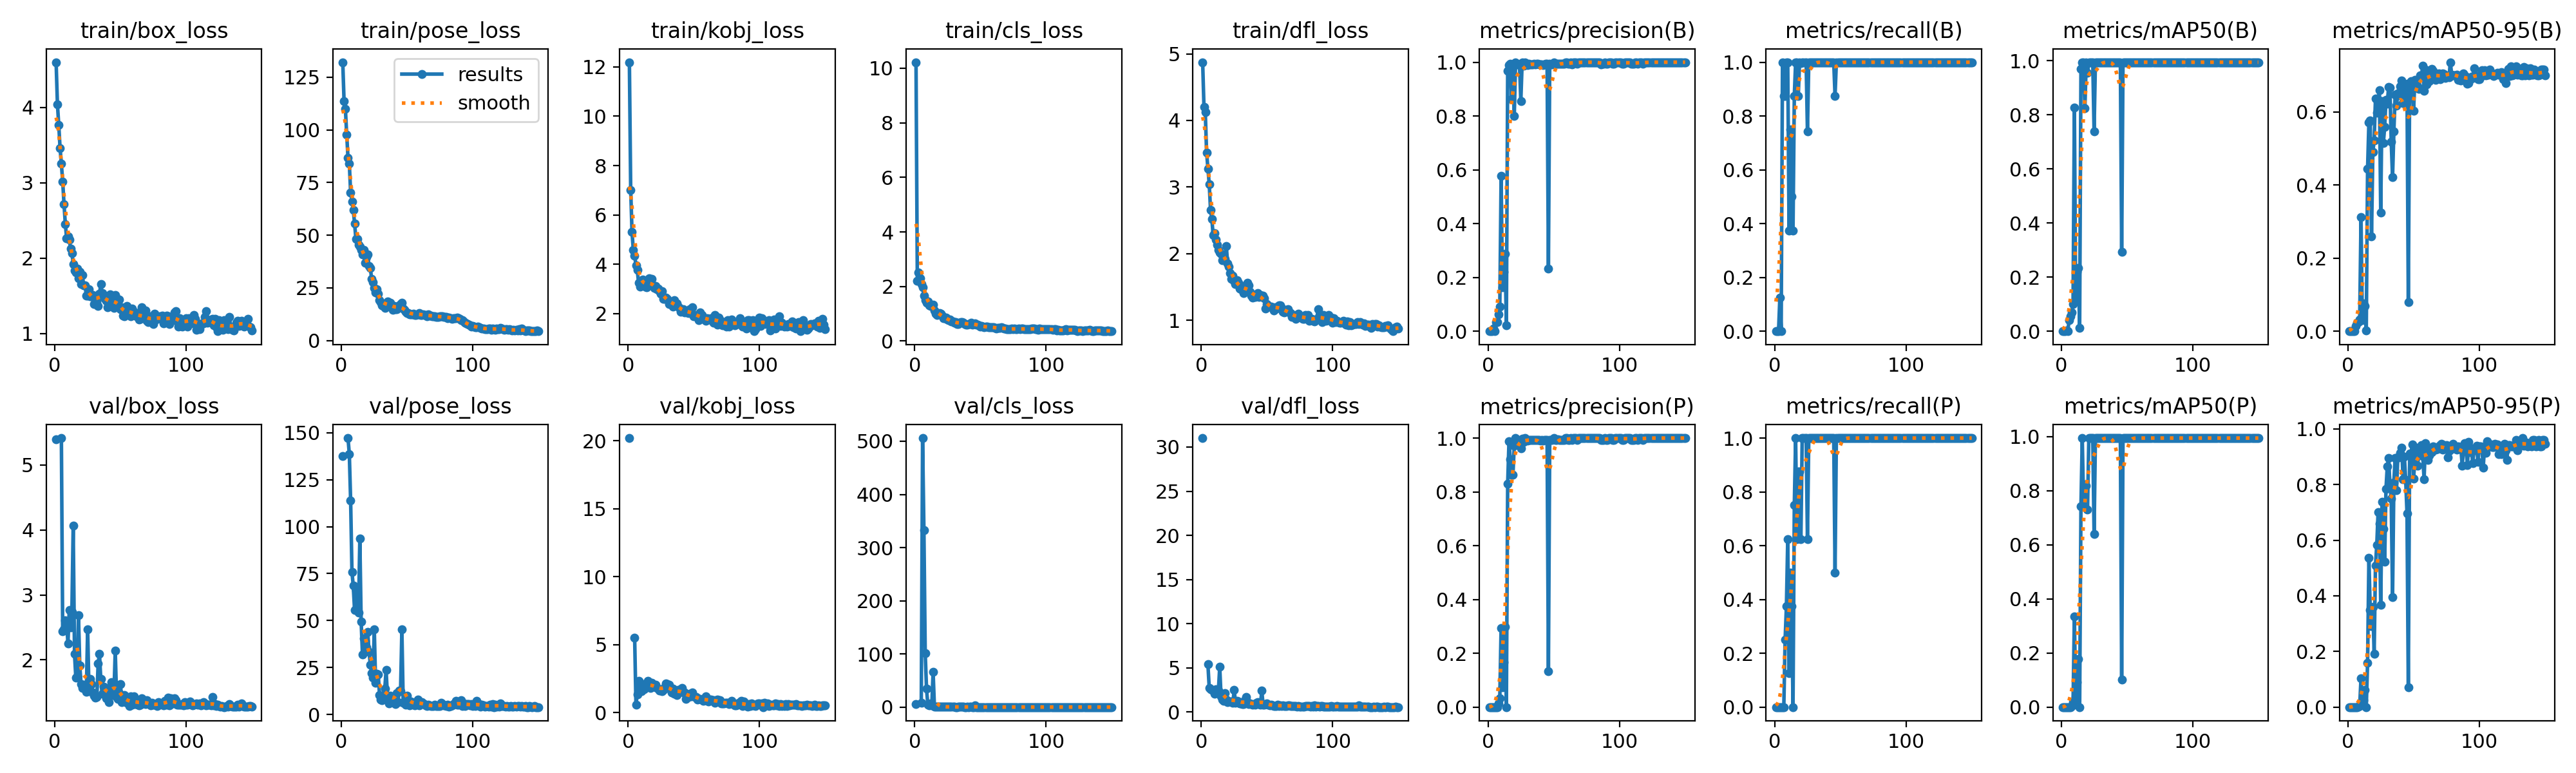

In [14]:
from IPython.display import Image
import os

# Ruta automática basada en el nombre que le dimos al entrenamiento
path_resultados = '/content/runs/pose/metrologia_chompas/v9_m1280_color_agnostic/results.png'

if os.path.exists(path_resultados):
    display(Image(filename=path_resultados, width=800))
else:
    print("El archivo aún no se ha generado. Espera a que termine al menos la primera época.")

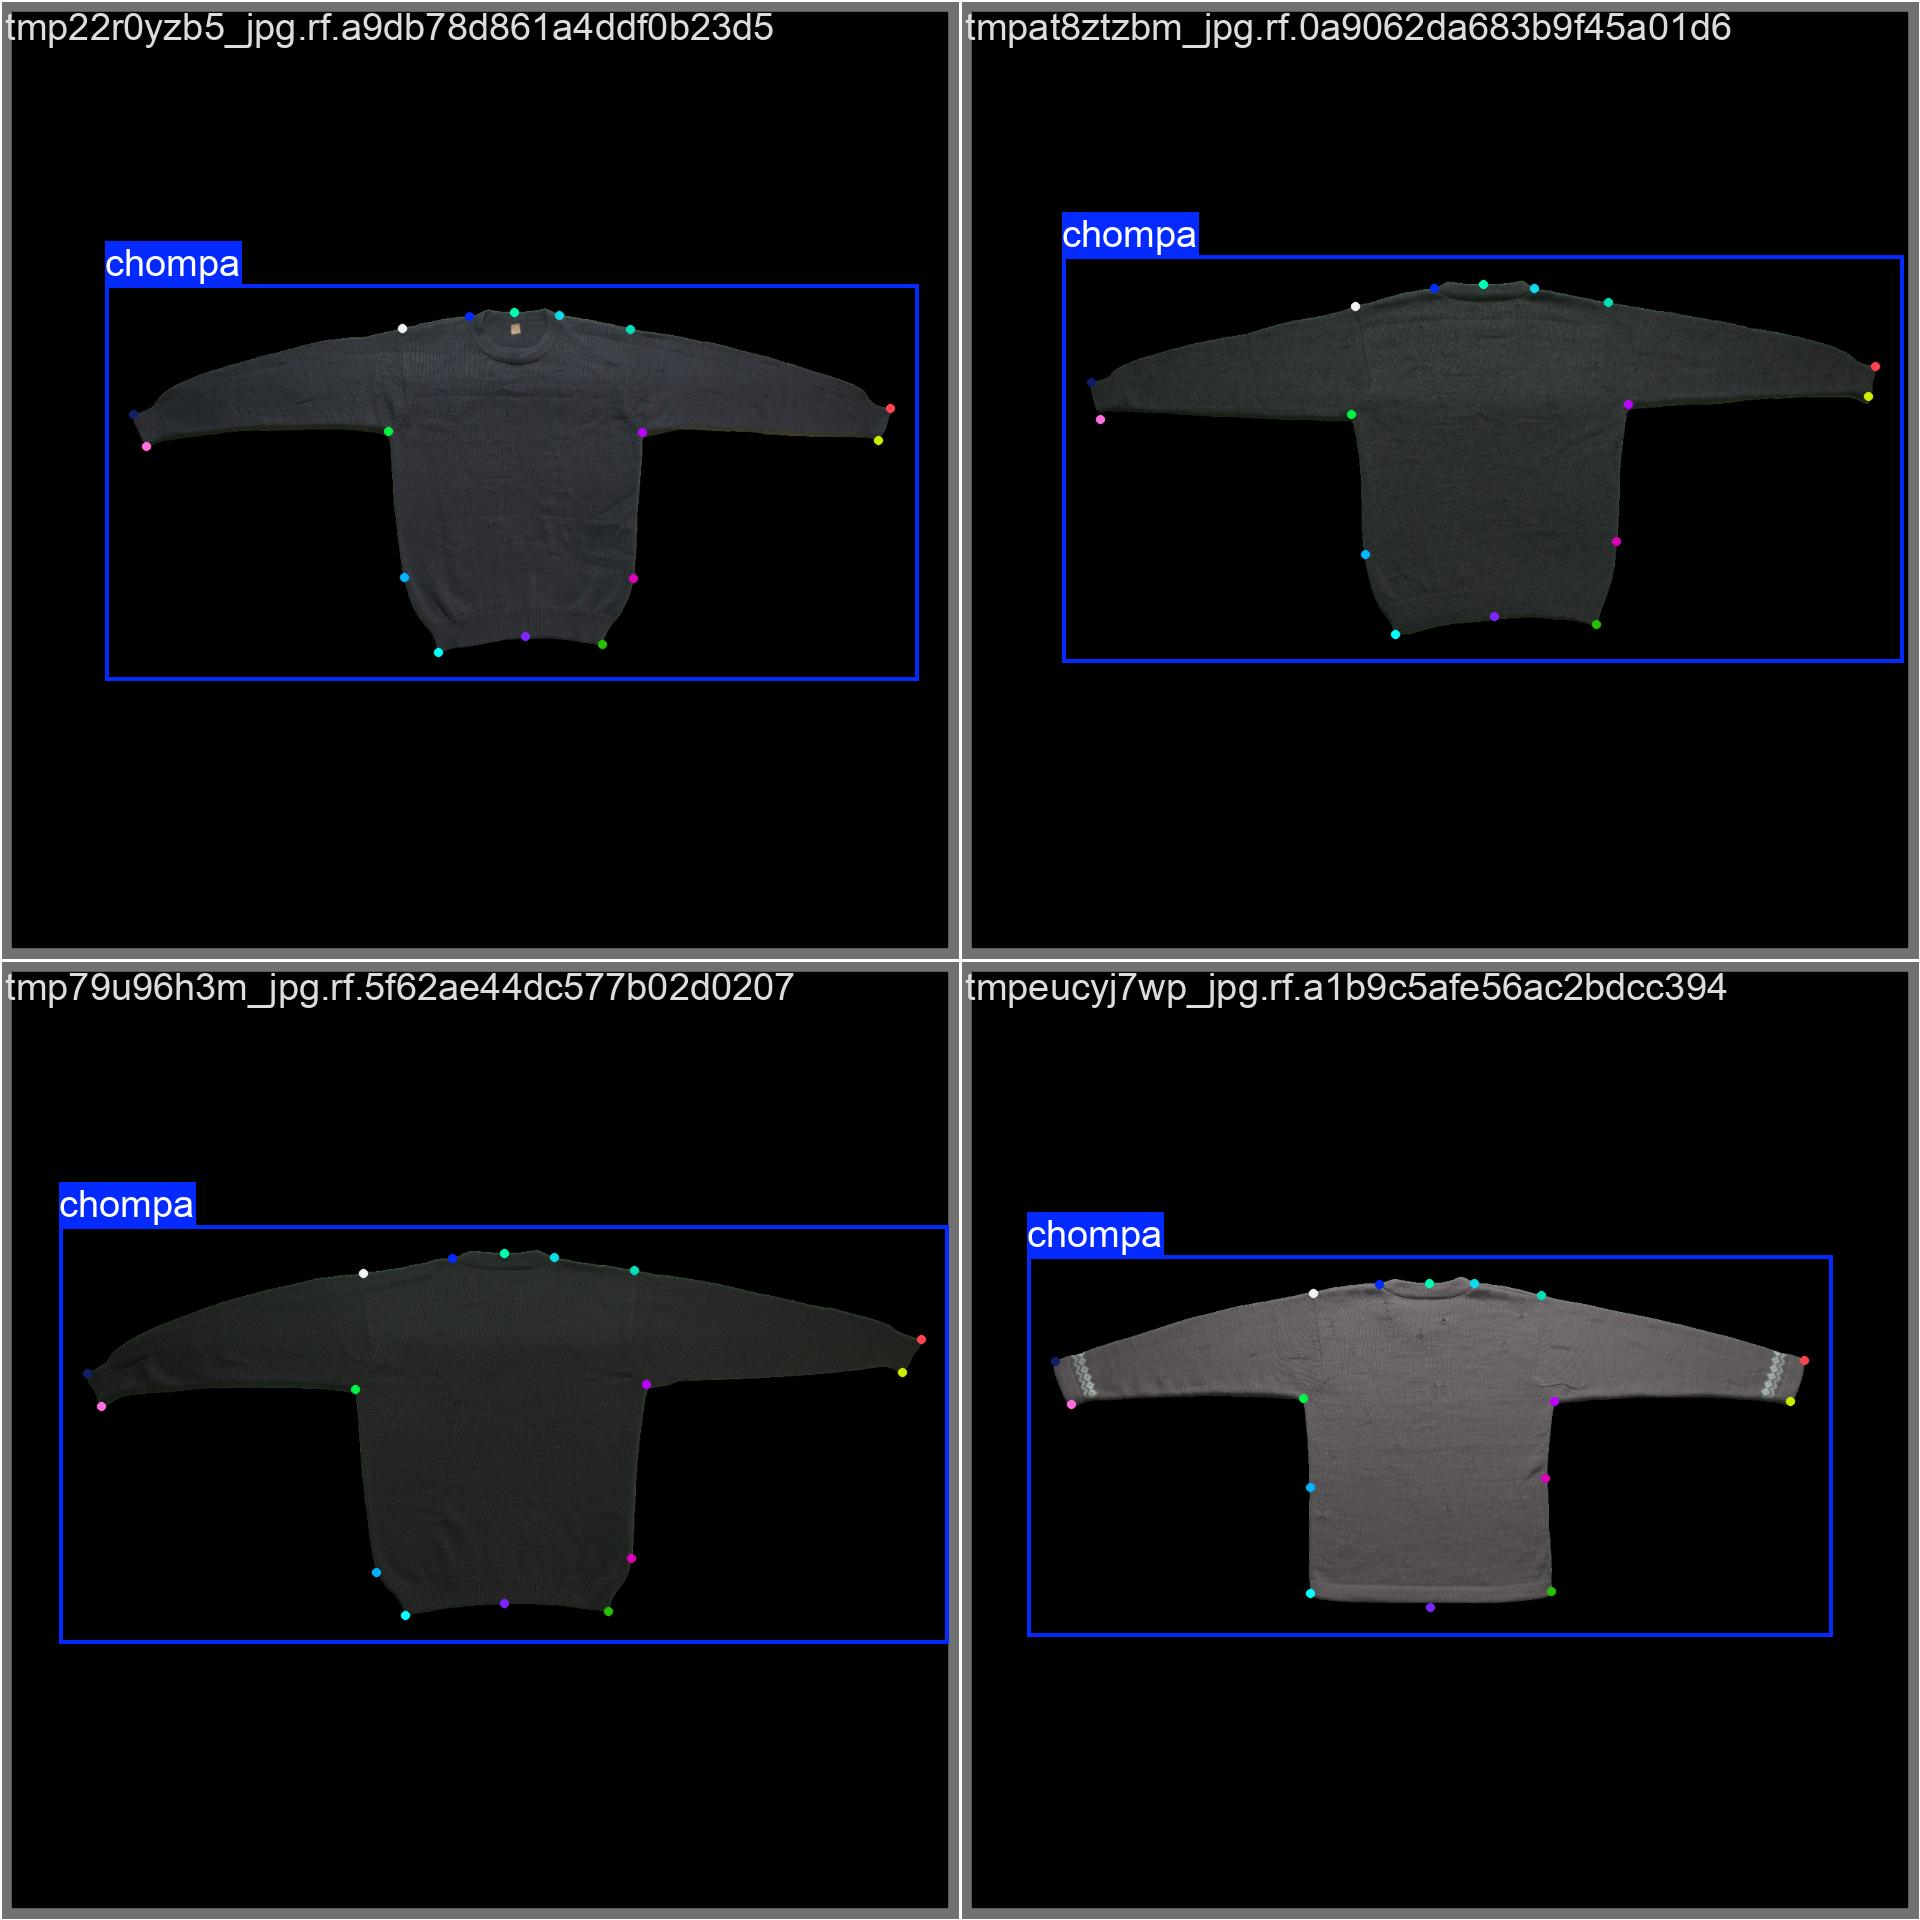

In [15]:
from IPython.display import Image
import os

# Ruta automática basada en el nombre que le dimos al entrenamiento
path_resultados = '/content/runs/pose/metrologia_chompas/v9_m1280_color_agnostic/val_batch0_labels.jpg'

if os.path.exists(path_resultados):
    display(Image(filename=path_resultados, width=800))
else:
    print("El archivo aún no se ha generado. Espera a que termine al menos la primera época.")

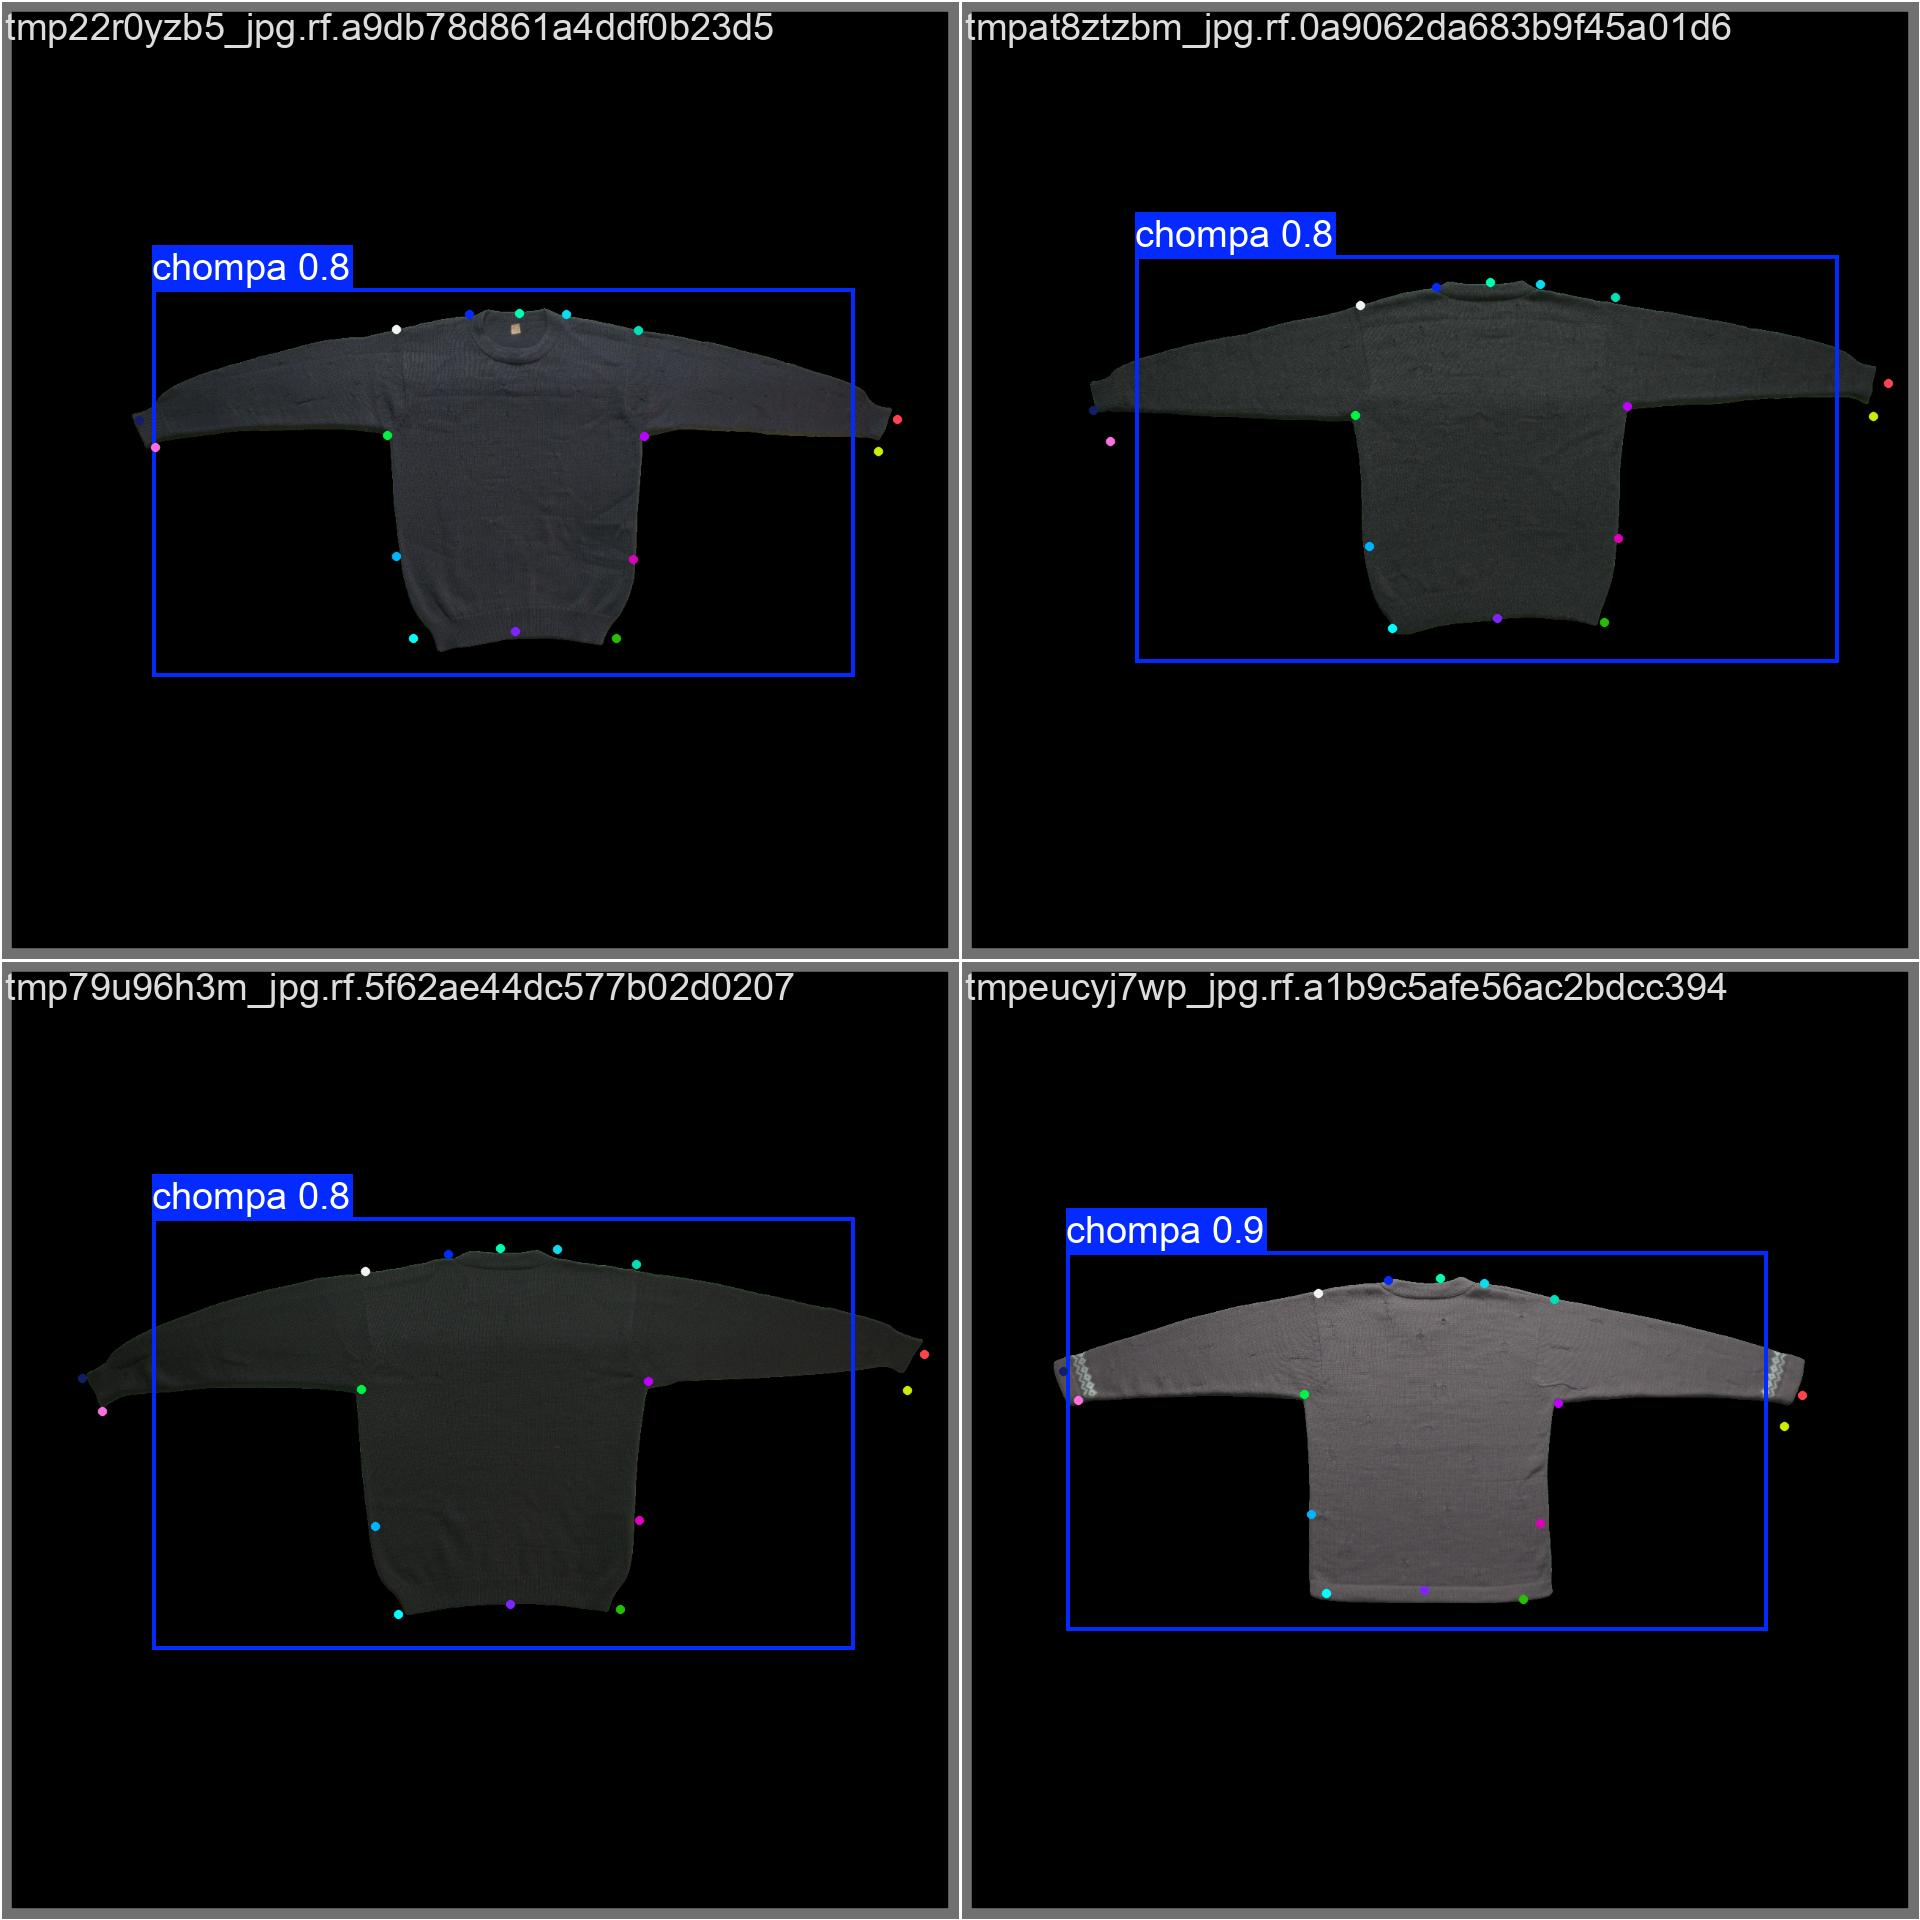

In [16]:
from IPython.display import Image
import os

# Ruta automática basada en el nombre que le dimos al entrenamiento
path_resultados = '/content/runs/pose/metrologia_chompas/v9_m1280_color_agnostic/val_batch0_pred.jpg'

if os.path.exists(path_resultados):
    display(Image(filename=path_resultados, width=800))
else:
    print("El archivo aún no se ha generado. Espera a que termine al menos la primera época.")

In [17]:
import pandas as pd

# Cambia la ruta por la carpeta de tu mejor modelo
path_results = '/content/runs/pose/metrologia_chompas/v9_m1280_color_agnostic/results.csv'
df = pd.read_csv(path_results)

# Limpiar espacios en los nombres de las columnas
df.columns = df.columns.str.strip()

# Obtener la última fila
final_metrics = df.iloc[-1]

print(f"📊 mAP50-95 (Pose): {final_metrics['metrics/mAP50-95(P)']: .4f}")
print(f"📊 mAP50 (Pose):    {final_metrics['metrics/mAP50(P)']: .4f}")

📊 mAP50-95 (Pose):  0.9463
📊 mAP50 (Pose):     0.9950


In [18]:
import cv2
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt

# 1. Cargar tu mejor modelo
model = YOLO('/content/runs/pose/metrologia_chompas/v9_m1280_color_agnostic/weights/best.pt')

# 2. Ruta de la imagen que quieres inspeccionar
img_path = '/content/valid_1024/images/tmpv39uhoig_jpg.rf.156642024267b2fc2254f9e16c160e4d.jpg'

# 3. Inferencia con umbral de confianza MUY BAJO (0.10)
# Esto nos mostrará si el modelo detectó los puños pero con baja seguridad.
results = model.predict(source=img_path, conf=0.10, imgsz=1024)

for r in results:
    img = r.orig_img.copy()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Extraer keypoints y sus confianzas
    # shape: [num_personas, num_keypoints, 3] -> (x, y, conf)
    kpts = r.keypoints.data[0].cpu().numpy()

    print(f"--- Análisis de Keypoints para: {img_path} ---")
    for i, kpt in enumerate(kpts):
        x, y, conf = kpt
        # Los puños suelen ser los últimos puntos según tu flip_idx (puntos 12, 13, 14, 15)
        print(f"Punto {i}: Coords({int(x)}, {int(y)}) - Confianza: {conf:.4f}")

        # Dibujar TODOS los puntos encontrados, incluso los de baja confianza
        color = (0, 255, 0) if conf > 0.5 else (255, 0, 0) # Verde si es bueno, Rojo si es dudoso
        cv2.circle(img, (int(x), int(y)), 5, color, -1)
        cv2.putText(img, str(i), (int(x), int(y)-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    plt.figure(figsize=(10,10))
    plt.imshow(img)
    plt.title("Visualización Forzada (Rojo = Baja Confianza)")
    plt.axis('off')
    plt.show()

FileNotFoundError: /content/valid_1024/images/tmpv39uhoig_jpg.rf.156642024267b2fc2254f9e16c160e4d.jpg does not exist

# Exportar data de entrenamiento

In [ ]:
# 1. Comprimir la carpeta 'runs'
!zip -r resultados_yolo.zip runs/

# 2. Descargar el archivo a tu PC
from google.colab import files
files.download('resultados_yolo.zip')